In [ ]:
import os
import pandas as pd

def tutor_inventory(paths):
    inventory = []
    for path in paths:
        db_name = os.path.basename(path)
        for root, dirs, files in os.walk(path):
            for file in files:
                if file.endswith('.csv'):
                    file_path = os.path.join(root, file)
                    size_mb = os.path.getsize(file_path) / (1024 * 1024)
                    inventory.append({
                        "Database": db_name,
                        "File Name": file,
                        "Size (MB)": round(size_mb, 2)
                    })
    
    df = pd.DataFrame(inventory)
    return df.sort_values(by=["Database", "Size (MB)"], ascending=[True, False])

# 지훈님의 실제 경로 설정
my_paths = [
    r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT",
    r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE"
]

inventory_df = tutor_inventory(my_paths)
print(inventory_df.to_string(index=False))

      Database                                                File Name  Size (MB)
PROD_FLOWPOINT                                 PAYABLE_TRANSACTIONS.csv       7.14
PROD_FLOWPOINT                              RECEIVABLE_TRANSACTIONS.csv       7.12
PROD_FLOWPOINT                                        COMPANY_LINKS.csv       6.65
PROD_FLOWPOINT                                             PAYABLES.csv       5.74
PROD_FLOWPOINT                                          RECEIVABLES.csv       5.70
PROD_FLOWPOINT                                      PAYABLE_DETAILS.csv       4.84
PROD_FLOWPOINT                                   RECEIVABLE_DETAILS.csv       4.77
PROD_FLOWPOINT                  PAYABLE_DETAIL_PAYABLE_TRANSACTIONS.csv       4.14
PROD_FLOWPOINT            RECEIVABLE_DETAIL_RECEIVABLE_TRANSACTIONS.csv       4.12
PROD_FLOWPOINT          RECEIVABLE_TRANSACTION_PAYABLE_TRANSACTIONS.csv       4.06
PROD_FLOWPOINT                                         TRANSACTIONS.csv       3.77
PROD

In [ ]:
import pandas as pd

# 1. 가장 중요해 보이는 기업 개요 파일을 불러옵니다.
df = pd.read_csv(r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_OVERVIEW.csv", encoding='utf-8-sig')

# 2. 데이터의 '골격' 확인 (몇 개의 기업 정보가 있는지?)
print(f"전체 데이터 행 수: {df.shape[0]}개, 컬럼 수: {df.shape[1]}개")

# 3. 데이터에 '구멍(결측치)'이 얼마나 있는지 확인 (매우 중요!)
print("\n[결측치 확인]")
print(df.isnull().sum().sort_values(ascending=False).head(10))

전체 데이터 행 수: 1753개, 컬럼 수: 42개

[결측치 확인]
_AB_CDC_DELETED_AT                 1753
COMPANY_STATUS_CHANGE_DATE         1706
GROUP_NAME                         1676
OVERDRAFT_TRANSACTION_BANK_CODE    1508
OVERDRAFT_TRANSACTION_BANK_NAME    1507
EMAIL                               997
FAX_NUMBER                          861
HOMEPAGE_URL                        732
TELEPHONE_NUMBER                    646
MAIN_PRODUCT                        483
dtype: int64


In [ ]:
import pandas as pd

# 1. 데이터 불러오기
file_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_OVERVIEW.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 결측치 비율이 90% 이상인 컬럼 삭제 (데이터 청소)
threshold = 0.9
df_cleaned = df.dropna(thresh=len(df) * (1 - threshold), axis=1)

print(f"청소 전 컬럼 수: {df.shape[1]}개 -> 청소 후 컬럼 수: {df_cleaned.shape[1]}개")

# 3. 남은 컬럼들의 '변수 성격' 파악 (고유값 개수)
# 고유값이 1개면 분석 가치가 없고, 행 수와 같으면 '식별자(ID)'일 확률이 높습니다.
unique_counts = df_cleaned.nunique().sort_values()
print("\n[컬럼별 고유값(Unique) 개수]")
print(unique_counts)

# 4. 분석 결과 저장 (나중에 쓰기 위해)
df_cleaned.to_csv("COMPANY_OVERVIEW_CLEANED.csv", index=False, encoding='utf-8-sig')

청소 전 컬럼 수: 42개 -> 청소 후 컬럼 수: 39개

[컬럼별 고유값(Unique) 개수]
_AIRBYTE_GENERATION_ID                   1
COMPANY_TYPE                             2
COMPANY_FORM_FR                          4
COMPANY_STATUS_CODE                      5
IPO_CODE                                 6
ACCOUNTING_END_DATE                      7
COMPANY_SIZE                             8
COMPANY_FCD                             10
BUSINESS_CLASSIFICATION_NAME_LARGE      20
_AIRBYTE_EXTRACTED_AT                   80
_AIRBYTE_META                           80
MASTER_TRANSACTION_BANK_NAME           109
MASTER_TRANSACTION_BANK_CODE           111
OVERDRAFT_TRANSACTION_BANK_CODE        172
OVERDRAFT_TRANSACTION_BANK_NAME        173
BUSINESS_CATEGORY_CODE                 471
BUSINESS_CATEGORY_NAME                 472
INFORMATION_STANDARD_DATE              618
EMAIL                                  655
FAX_NUMBER                             753
_AB_CDC_UPDATED_AT                     866
_AB_CDC_LSN                            866

In [23]:
import pandas as pd

# 1. 청소된 데이터 불러오기 (이전 단계에서 저장한 파일)
df = pd.read_csv("COMPANY_OVERVIEW_CLEANED.csv", encoding='utf-8-sig')

# 2. 기업 규모(COMPANY_SIZE) 분포 확인
print("=== 기업 규모별 분포 ===")
size_dist = df['COMPANY_SIZE'].value_counts()
print(size_dist)

# 3. 대분류 업종(BUSINESS_CLASSIFICATION_NAME_LARGE) TOP 5 확인
print("\n=== 주요 업종 TOP 5 ===")
industry_top5 = df['BUSINESS_CLASSIFICATION_NAME_LARGE'].value_counts().head(5)
print(industry_top5)

# 4. (보너스) 기업 규모별 비율(%) 계산
print("\n=== 기업 규모별 비율 (%) ===")
size_pct = df['COMPANY_SIZE'].value_counts(normalize=True) * 100
print(size_pct.round(1))

=== 기업 규모별 분포 ===
COMPANY_SIZE
3.0    734
2.0    445
6.0    266
5.0     76
1.0     69
8.0     21
7.0     18
4.0      6
Name: count, dtype: int64

=== 주요 업종 TOP 5 ===
BUSINESS_CLASSIFICATION_NAME_LARGE
제조업                 739
도매 및 소매업            369
정보통신업               245
건설업                 102
전문, 과학 및 기술 서비스업     97
Name: count, dtype: int64

=== 기업 규모별 비율 (%) ===
COMPANY_SIZE
3.0    44.9
2.0    27.2
6.0    16.3
5.0     4.6
1.0     4.2
8.0     1.3
7.0     1.1
4.0     0.4
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# 1. 신용등급 데이터 불러오기
file_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_CREDIT_GRADE.csv"
df_grade = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 기본 정보 확인
print(f"전체 행 수: {df_grade.shape[0]}개, 컬럼 수: {df_grade.shape[1]}개")

# 3. 결측치 확인
print("\n[결측치 확인]")
print(df_grade.isnull().sum().sort_values(ascending=False).head(10))

# 4. 컬럼별 고유값 개수 (카디널리티) 확인
print("\n[컬럼별 고유값 개수]")
print(df_grade.nunique().sort_values())

# 5. 실제 등급(CREDIT_GRADE)의 종류와 분포 확인
print("\n[신용등급 분포]")
print(df_grade['CREDIT_GRADE'].value_counts())

전체 행 수: 9461개, 컬럼 수: 16개

[결측치 확인]
_AB_CDC_DELETED_AT          9461
SETTLEMENT_BASE_DATE        1572
CREDIT_GRADE                   1
CREDIT_GRADE_DESCRIPTION       1
GRADE_CLASSIFICATION           1
EVALUATION_DATE                1
CREDIT_GRADE_NAME              1
_AIRBYTE_RAW_ID                0
_AB_CDC_LSN                    0
CREATED_AT                     0
dtype: int64

[컬럼별 고유값 개수]
_AB_CDC_DELETED_AT             0
_AIRBYTE_GENERATION_ID         1
GRADE_CLASSIFICATION           6
CREDIT_GRADE_DESCRIPTION      13
CREDIT_GRADE                  23
CREDIT_GRADE_NAME             41
SETTLEMENT_BASE_DATE          55
_AIRBYTE_EXTRACTED_AT         80
_AIRBYTE_META                 80
_AB_CDC_UPDATED_AT           960
COMPANY_ID                  1324
EVALUATION_DATE             1692
_AB_CDC_LSN                 3704
CREATED_AT                  9394
ID                          9461
_AIRBYTE_RAW_ID             9461
dtype: int64

[신용등급 분포]
CREDIT_GRADE
15.0    1378
16.0    1129
13.0    1035
17.0

In [ ]:
import pandas as pd

# 1. 신용등급 데이터 로드
file_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_CREDIT_GRADE.csv"
df_grade = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 날짜 컬럼을 판다스가 이해할 수 있는 '날짜 타입'으로 변경
# (EVALUATION_DATE가 고유값이 1,692개이므로 이를 기준으로 정렬합니다)
df_grade['EVALUATION_DATE'] = pd.to_datetime(df_grade['EVALUATION_DATE'])

# 3. 최신 데이터만 남기기 위한 정렬 (기업별로 최신 날짜가 위로 오게)
df_grade_sorted = df_grade.sort_values(by=['COMPANY_ID', 'EVALUATION_DATE'], ascending=[True, False])

# 4. 중복 제거: 각 COMPANY_ID에서 첫 번째(가장 최신) 행만 남김
df_grade_latest = df_grade_sorted.drop_duplicates(subset=['COMPANY_ID'], keep='first')

print(f"중복 제거 전: {len(df_grade)}행 -> 중복 제거 후: {len(df_grade_latest)}행")

# 5. 특수 코드(99.0) 제외한 등급 통계 확인
clean_grades = df_grade_latest[df_grade_latest['CREDIT_GRADE'] != 99.0]
print("\n[정상 기업의 최신 등급 통계]")
print(clean_grades['CREDIT_GRADE'].describe())

중복 제거 전: 9461행 -> 중복 제거 후: 1324행

[정상 기업의 최신 등급 통계]
count    1283.000000
mean       13.049883
std         4.276592
min         1.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        22.000000
Name: CREDIT_GRADE, dtype: float64


In [26]:
import pandas as pd

# 1. 두 파일 로드
df_overview = pd.read_csv("COMPANY_OVERVIEW_CLEANED.csv", encoding='utf-8-sig')
# (위에서 작업한 df_grade_latest를 사용합니다)

# 2. 데이터 병합 (Merge)
# 'COMPANY_ID'를 기준으로 두 조각을 하나로 합칩니다.
# 'inner' 조인을 사용하여 두 정보가 모두 있는 기업만 남깁니다.
df_final = pd.merge(df_overview, df_grade_latest[['COMPANY_ID', 'CREDIT_GRADE', 'EVALUATION_DATE']], 
                     on='COMPANY_ID', how='inner')

# 3. 데이터 손실 확인 (과학적 검증)
print(f"Overview 기업 수: {len(df_overview)}개")
print(f"최종 합쳐진 기업 수: {len(df_final)}개")

# 4. 첫 번째 인사이트: 업종별 평균 등급 확인
# 제조업(1위 업종)이 정말 리스크가 큰지 수치로 확인해봅시다.
industry_analysis = df_final.groupby('BUSINESS_CLASSIFICATION_NAME_LARGE')['CREDIT_GRADE'].agg(['mean', 'count', 'std'])
industry_analysis = industry_analysis.sort_values(by='mean', ascending=False) # 평균 등급이 높은(위험한) 순서

print("\n=== 업종별 리스크 성적표 (상위 10개) ===")
print(industry_analysis.head(10))

# 결과 저장
df_final.to_csv("FINAL_MERGED_DATA.csv", index=False, encoding='utf-8-sig')

Overview 기업 수: 1753개
최종 합쳐진 기업 수: 1551개

=== 업종별 리스크 성적표 (상위 10개) ===
                                         mean  count        std
BUSINESS_CLASSIFICATION_NAME_LARGE                             
금융 및 보험업                            60.241379     29  43.910343
전기, 가스, 증기 및 공기조절 공급업               42.666667      3  48.788660
농업, 임업 및 어업                         42.166667      6  44.246657
부동산업                                27.000000      8  29.262360
예술, 스포츠 및 여가관련 서비스업                 24.600000     10  26.239072
전문, 과학 및 기술 서비스업                    20.644444     90  23.203211
광업                                  19.000000      1        NaN
건설업                                 15.760870     92  18.450629
숙박 및 음식점업                           15.750000     12   4.287932
교육 서비스업                             15.250000      4   4.349329


=== [정화된] 업종별 리스크 성적표 ===
                                         mean  count       std
BUSINESS_CLASSIFICATION_NAME_LARGE                            
전문, 과학 및 기술 서비스업                    14.036145     83  4.004405
제조업                                 12.885294    680  4.383839
도매 및 소매업                            12.842949    312  4.278603
정보통신업                               12.799127    229  4.061350
건설업                                 11.977273     88  4.799371


C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\cozy1\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47588 

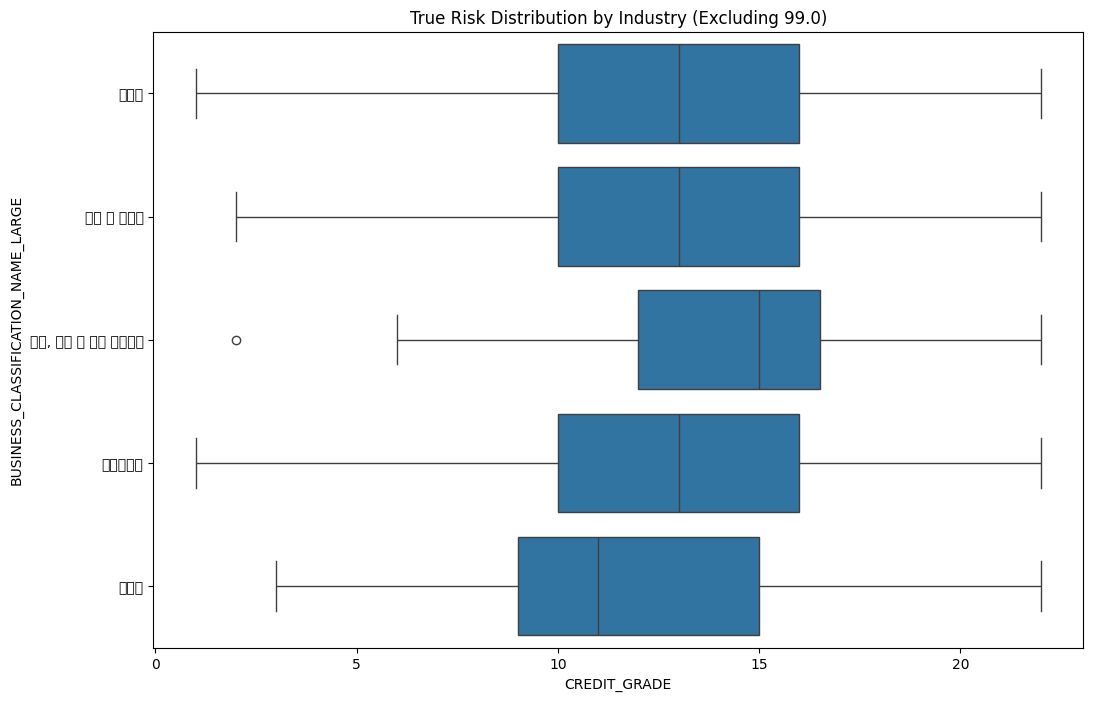

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 이전 단계에서 합친 데이터 로드
df_final = pd.read_csv("FINAL_MERGED_DATA.csv", encoding='utf-8-sig')

# 2. 99.0 코드 제거 (정상 등급 기업만 필터링)
df_clean = df_final[df_final['CREDIT_GRADE'] <= 22]

# 3. 표본 수가 일정 수준(예: 30개) 이상인 업종만 선택
# 너무 적은 표본은 통계적 오류를 범하기 쉽습니다.
industry_counts = df_clean['BUSINESS_CLASSIFICATION_NAME_LARGE'].value_counts()
top_industries = industry_counts[industry_counts >= 30].index

df_filtered = df_clean[df_clean['BUSINESS_CLASSIFICATION_NAME_LARGE'].isin(top_industries)]

# 4. 재분석 결과 출력
true_risk = df_filtered.groupby('BUSINESS_CLASSIFICATION_NAME_LARGE')['CREDIT_GRADE'].agg(['mean', 'count', 'std']).sort_values('mean', ascending=False)

print("=== [정화된] 업종별 리스크 성적표 ===")
print(true_risk)

# 5. 시각화 (박스플롯) - 데이터의 분포를 한눈에 보기
plt.figure(figsize=(12, 8))
sns.boxplot(x='CREDIT_GRADE', y='BUSINESS_CLASSIFICATION_NAME_LARGE', data=df_filtered)
plt.title('True Risk Distribution by Industry (Excluding 99.0)')
plt.show()

In [ ]:
import pandas as pd

# 1. 거래 데이터 로드
file_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\PAYABLE_TRANSACTIONS.csv"
df_trans = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 데이터 구조 및 타입 확인
print("=== [PAYABLE_TRANSACTIONS] 구조 확인 ===")
print(df_trans.info())

# 3. 상위 데이터 5개만 맛보기 (실제 데이터 형태 확인)
print("\n=== 데이터 샘플 ===")
print(df_trans.head())

# 4. 결측치 비율 확인 (데이터의 투명도)
print("\n[결측치 확인]")
print(df_trans.isnull().sum().sort_values(ascending=False).head(10))

=== [PAYABLE_TRANSACTIONS] 구조 확인 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24708 entries, 0 to 24707
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   _AIRBYTE_RAW_ID         24708 non-null  object 
 1   _AIRBYTE_EXTRACTED_AT   24708 non-null  object 
 2   _AIRBYTE_META           24708 non-null  object 
 3   _AIRBYTE_GENERATION_ID  24708 non-null  int64  
 4   ID                      24708 non-null  int64  
 5   NOTE                    16046 non-null  object 
 6   AMOUNT                  24708 non-null  int64  
 7   USER_ID                 24708 non-null  int64  
 8   CATEGORY                24708 non-null  object 
 9   CANCEL_ID               8030 non-null   float64
 10  COMPANY_ID              22082 non-null  float64
 11  CREATED_AT              24708 non-null  object 
 12  DELETED_AT              0 non-null      float64
 13  TRADE_DATE              24708 non-null  object 
 14  U

In [ ]:
import pandas as pd

# 1. 데이터 로드
df_trans = pd.read_csv(r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\PAYABLE_TRANSACTIONS.csv", encoding='utf-8-sig')

# 2. 취소 거래 비율 계산
cancel_rate = df_trans['IS_CANCELED'].value_counts(normalize=True) * 100
print(f"=== 전체 거래 중 취소 비중 (%): \n{cancel_rate.round(2)}")

# 3. 실질 거래(취소 제외)의 금액 통계
# scikit-learn 모델링 시 이상치 처리를 위해 반드시 확인해야 합니다.
real_trans = df_trans[df_trans['IS_CANCELED'] == False]
print("\n=== 실질 거래 금액 통계 (AMOUNT) ===")
print(real_trans['AMOUNT'].describe().apply(lambda x: format(x, ',')))

# 4. 고유 기업 수 확인
print(f"\n거래 데이터 내 고유 기업 수(COMPANY_ID): {df_trans['COMPANY_ID'].nunique()}개")

=== 전체 거래 중 취소 비중 (%): 
IS_CANCELED
False    67.56
True     32.44
Name: proportion, dtype: float64

=== 실질 거래 금액 통계 (AMOUNT) ===
count               16,692.0
mean     41,866,022.06170621
std      60,222,960.61423124
min                      0.0
25%             15,000,000.0
50%             25,000,000.0
75%             45,000,000.0
max          1,000,000,000.0
Name: AMOUNT, dtype: object

거래 데이터 내 고유 기업 수(COMPANY_ID): 681개


In [ ]:
import pandas as pd
import numpy as np

# 1. 데이터 로드
df_trans = pd.read_csv(r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\PAYABLE_TRANSACTIONS.csv", encoding='utf-8-sig')

# 2. 데이터 사이언티스트의 정제 (취소 거래 제외)
real_df = df_trans[df_trans['IS_CANCELED'] == False].copy()

# 3. 기업별 핵심 지표(Feature) 생성
# - 총 거래횟수, 총 거래액, 평균 거래액, 거래액의 변동성(표준편차)
company_features = real_df.groupby('COMPANY_ID').agg(
    total_trans_count=('ID', 'count'),
    total_amount=('AMOUNT', 'sum'),
    avg_amount=('AMOUNT', 'mean'),
    std_amount=('AMOUNT', 'std')
).reset_index()

# 4. 변동계수(CV) 계산: 거래가 얼마나 일정하게 일어나는가?
# CV = 표준편차 / 평균
company_features['amount_cv'] = company_features['std_amount'] / company_features['avg_amount']

# 5. 결과 확인
print("=== 기업별 거래 프로필 요약 (상위 5개) ===")
print(company_features.head())

# 저장
company_features.to_csv("COMPANY_TRANSACTION_FEATURES.csv", index=False, encoding='utf-8-sig')

=== 기업별 거래 프로필 요약 (상위 5개) ===
   COMPANY_ID  total_trans_count  total_amount    avg_amount    std_amount  \
0         4.0                  2     776776000  3.883880e+08  0.000000e+00   
1         6.0                  2      23617200  1.180860e+07  0.000000e+00   
2         7.0                  2      32446980  1.622349e+07  0.000000e+00   
3        10.0                 12     140800000  1.173333e+07  3.904425e+06   
4        11.0                  4     200000000  5.000000e+07  0.000000e+00   

   amount_cv  
0   0.000000  
1   0.000000  
2   0.000000  
3   0.332763  
4   0.000000  


In [ ]:
import pandas as pd

# 1. 파일 로드 (11.05MB로 덩치가 크니 앞부분만 살짝 읽어봅시다)
pension_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_PENSION_EMPLOYEE_STATISTICS.csv"
df_pension = pd.read_csv(pension_path, encoding='utf-8-sig', nrows=5)

# 2. 모든 컬럼명을 리스트로 출력
print("=== [PENSION_STATISTICS] 실제 컬럼 리스트 ===")
print(df_pension.columns.tolist())

# 3. 데이터가 어떻게 생겼는지 한 줄만 보기 (가로로 길게 출력될 수 있음)
print("\n=== 데이터 실제 값 샘플 ===")
display(df_pension.head(1))

=== [PENSION_STATISTICS] 실제 컬럼 리스트 ===
['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META', '_AIRBYTE_GENERATION_ID', 'ID', 'COMPANY_ID', 'CREATED_AT', 'JOIN_COUNT', '_AB_CDC_LSN', 'STANDARD_DATE', '_AB_CDC_DELETED_AT', '_AB_CDC_UPDATED_AT']

=== 데이터 실제 값 샘플 ===


,_AIRBYTE_RAW_ID,_AIRBYTE_EXTRACTED_AT,_AIRBYTE_META,_AIRBYTE_GENERATION_ID,ID,COMPANY_ID,CREATED_AT,JOIN_COUNT,_AB_CDC_LSN,STANDARD_DATE,_AB_CDC_DELETED_AT,_AB_CDC_UPDATED_AT
0,20f85c2a-81bc-4e17-980d-c4756ddeb952,2025-10-14 11:26:32.305000+00:00,"{\n ""changes"": [],\n ""sync_id"": 23\n}",0,1,1,2024-12-17 09:29:15.789074,5,93886392.0,202410,NaN,2025-10-14T11:26:32.305225016Z


In [ ]:
import pandas as pd

# 1. 고용 데이터 전체 로드 (11.05MB)
file_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_PENSION_EMPLOYEE_STATISTICS.csv"
df_pension = pd.read_csv(file_path, encoding='utf-8-sig')

# 2. 분석에 필요한 컬럼만 추출 (다이어트)
df_sub = df_pension[['COMPANY_ID', 'STANDARD_DATE', 'JOIN_COUNT']].copy()

# 3. 기업별 요약 통계
# - 가장 최근 인원(Latest), 평균 인원(Mean), 고용 변동성(Std)
pension_features = df_sub.groupby('COMPANY_ID').agg(
    current_employees=('JOIN_COUNT', 'last'),
    avg_employees=('JOIN_COUNT', 'mean'),
    emp_volatility=('JOIN_COUNT', 'std'),
    obs_months=('STANDARD_DATE', 'count') # 몇 개월치 데이터가 있는지
).reset_index()

# 4. 고용 규모 TOP 5 기업 확인
print("=== 기업별 고용 규모 (TOP 5) ===")
print(pension_features.sort_values('current_employees', ascending=False).head())

# 5. 저장 (나중에 최종 머지에 사용)
pension_features.to_csv("COMPANY_PENSION_FEATURES.csv", index=False, encoding='utf-8-sig')

=== 기업별 고용 규모 (TOP 5) ===
     COMPANY_ID  current_employees  avg_employees  emp_volatility  obs_months
26           44             125039  116202.291667     7997.579941          72
25           43              40560   37303.288136     2163.672708          59
446         591              22428   19370.870370     2208.081794          54
22           36              21322   21891.515152      659.090241          66
29           48              17500    8156.203390     8386.917583          59


In [ ]:
import pandas as pd

# 1. 재무제표(Financial Statement)와 링크(Links) 데이터 샘플 로드
fin_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_FINANCIAL_STATEMENT.csv"
link_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\COMPANY_LINKS.csv"

df_fin = pd.read_csv(fin_path, encoding='utf-8-sig', nrows=5)
df_link = pd.read_csv(link_path, encoding='utf-8-sig', nrows=5)

# 2. 재무제표 컬럼 확인 (너무 많으니 개수와 주요 샘플만)
print(f"=== [FINANCIAL_STATEMENT] 구조 ===")
print(f"전체 컬럼 수: {len(df_fin.columns)}개")
print(f"주요 컬럼 샘플: {df_fin.columns.tolist()[:15]}") # 앞의 15개만 확인

# 3. 링크 데이터 확인
print("\n=== [COMPANY_LINKS] 구조 및 샘플 ===")
print(df_link.columns.tolist())
display(df_link.head(2))

=== [FINANCIAL_STATEMENT] 구조 ===
전체 컬럼 수: 392개
주요 컬럼 샘플: ['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META', '_AIRBYTE_GENERATION_ID', 'ID', 'FS_VAL1', 'FS_VAL2', 'FS_VAL3', 'FS_VAL4', 'FS_VAL5', 'FS_VAL6', 'FS_VAL7', 'FS_VAL8', 'FS_VAL9', 'FS_VAL10']

=== [COMPANY_LINKS] 구조 및 샘플 ===
['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META', '_AIRBYTE_GENERATION_ID', 'ID', 'AMOUNT', 'CATEGORY', 'COMPANY_ID', 'CREATED_AT', 'DELETED_AT', 'TRADE_DATE', 'UPDATED_AT', '_AB_CDC_LSN', 'REFERENCE_ID', 'REFERENCE_TABLE', '_AB_CDC_DELETED_AT', '_AB_CDC_UPDATED_AT', 'ANOTHER_COMPANY_ID']


,_AIRBYTE_RAW_ID,_AIRBYTE_EXTRACTED_AT,_AIRBYTE_META,_AIRBYTE_GENERATION_ID,ID,AMOUNT,CATEGORY,COMPANY_ID,CREATED_AT,DELETED_AT,TRADE_DATE,UPDATED_AT,_AB_CDC_LSN,REFERENCE_ID,REFERENCE_TABLE,_AB_CDC_DELETED_AT,_AB_CDC_UPDATED_AT,ANOTHER_COMPANY_ID
0,afadcc87-f133-4d4b-adb9-8cd3273a9973,2025-10-18 02:48:35.772000+00:00,"{\n ""changes"": [],\n ""sync_id"": 24\n}",0,1,500000000,receivable,95,2022-04-20 18:02:56.386000,NaN,2020-02-13,2022-04-20 18:02:57.079000,2.869635e+13,3,receivables,NaN,2025-10-18T02:48:35.772833664Z,94
1,c6e046ba-023a-447e-ba71-3212bc9850a0,2025-10-18 02:48:35.772000+00:00,"{\n ""changes"": [],\n ""sync_id"": 24\n}",0,2,500000000,receivable,366,2022-04-20 18:02:57.065000,NaN,2020-02-13,2022-11-30 18:05:35.584000,2.869635e+13,4,receivables,NaN,2025-10-18T02:48:35.772833664Z,94


In [ ]:
import pandas as pd

# 1. 경로 설정 (raw string 'r'을 붙여 SyntaxWarning 방지)
base_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data"
excel_path = rf"{base_path}\운영DB 스키마 명세.xlsx"
path_score = rf"{base_path}\PROD_FLOWSCORE\PUBLIC"

# 2. 명세서 로드 및 매핑 생성 (대문자로 통일하여 매칭률 제고)
schema_score = pd.read_excel(excel_path, sheet_name='PROD_FLOWSCORE')

def get_mapping_safe(df, table_name):
    target = df[df['table_name'] == table_name]
    # 물리 컬럼명을 대문자로 바꾸어 딕셔너리 생성
    return {str(k).upper(): v for k, v in zip(target['column_name'], target['logical_column_name'])}

bs_map = get_mapping_safe(schema_score, 'company_financial_statement')
is_map = get_mapping_safe(schema_score, 'company_income_statement')

# 3. 데이터 로드 및 변환
df_bs = pd.read_csv(rf"{path_score}\COMPANY_FINANCIAL_STATEMENT.csv", encoding='utf-8-sig')
# 데이터프레임 컬럼명도 대문자로 변환 후 매핑 적용
df_bs.columns = [col.upper() for col in df_bs.columns]
df_bs_labeled = df_bs.rename(columns=bs_map)

# 결과 확인 (한글 컬럼명이 나오는지 확인)
print(df_bs_labeled.filter(like='자산').head())

           자산       유동자산       당좌자산  현금 및 현금성 자산  외화현금 및 현금성 자산  단기투자자산  \
0   3742196.0   996540.0   951492.0     204171.0            NaN     NaN   
1   3969242.0  3619261.0   784068.0     133037.0            NaN     NaN   
2  13902077.0  7061183.0  6081080.0     919532.0            NaN     NaN   
3   1433740.0  1423740.0  1423740.0       1385.0            NaN     NaN   
4    170777.0   160777.0   160777.0     117091.0            NaN     NaN   

   파생상품자산  이영법인세자산  기타당좌자산       재고자산  ...     기타유형자산       무형자산  사용자수익기부자산  \
0     NaN      NaN     NaN    45048.0  ...  3037006.0   854495.0        NaN   
1     NaN      NaN     NaN  2835193.0  ...    27245.0   290210.0        NaN   
2     NaN      NaN     NaN   980103.0  ...  1002438.0  4066742.0        NaN   
3     NaN      NaN     NaN        NaN  ...        NaN        NaN        NaN   
4     NaN      NaN     NaN        NaN  ...        NaN        NaN        NaN   

   리스자산  기타무형자산   기타비유동자산  이연자산  (퇴직연금운용자산)  자산재평가이익  자산재평가손실(-)  
0   NaN

In [ ]:
import pandas as pd

# 1. 파일 로드
base_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data"
is_path = rf"{base_path}\PROD_FLOWSCORE\PUBLIC\COMPANY_INCOME_STATEMENT.csv"
df_is = pd.read_csv(is_path, encoding='utf-8-sig', nrows=5)

# 2. 현재 컬럼명 확인 (대소문자 확인용)
print("=== [IS] 현재 파일의 실제 컬럼명 ===")
print(df_is.columns.tolist())

# 3. 스키마 명세서와 비교 (대문자로 강제 통일하여 매칭)
schema_score = pd.read_excel(rf"{base_path}\운영DB 스키마 명세.xlsx", sheet_name='PROD_FLOWSCORE')
is_schema = schema_score[schema_score['table_name'] == 'company_income_statement']

# 매핑 딕셔너리를 생성할 때, 키값을 대문자로 바꿉니다.
is_map_upper = {str(k).upper(): v for k, v in zip(is_schema['column_name'], is_schema['logical_column_name'])}

print("\n=== [Mapping] 번역표 샘플 (대문자 기준) ===")
# 'FS_VAL1'이 '매출액'으로 잘 등록되어 있는지 확인
print({k: is_map_upper[k] for k in list(is_map_upper)[:5]})

# 4. 안전하게 변환 적용
df_is.columns = [col.upper() for col in df_is.columns] # 데이터 컬럼도 대문자로 통일
df_is_labeled = df_is.rename(columns=is_map_upper)

print("\n=== [성공] 변환 후 컬럼명 ===")
print(df_is_labeled.columns.tolist()[:10])

=== [IS] 현재 파일의 실제 컬럼명 ===
['_AIRBYTE_RAW_ID', '_AIRBYTE_EXTRACTED_AT', '_AIRBYTE_META', '_AIRBYTE_GENERATION_ID', 'ID', 'FS_VAL1', 'FS_VAL2', 'FS_VAL3', 'FS_VAL4', 'FS_VAL5', 'FS_VAL6', 'FS_VAL7', 'FS_VAL8', 'FS_VAL9', 'FS_VAL10', 'FS_VAL11', 'FS_VAL12', 'FS_VAL13', 'FS_VAL14', 'FS_VAL15', 'FS_VAL16', 'FS_VAL17', 'FS_VAL18', 'FS_VAL19', 'FS_VAL20', 'FS_VAL21', 'FS_VAL22', 'FS_VAL23', 'FS_VAL24', 'FS_VAL25', 'FS_VAL26', 'FS_VAL27', 'FS_VAL28', 'FS_VAL29', 'FS_VAL30', 'FS_VAL31', 'FS_VAL32', 'FS_VAL33', 'FS_VAL34', 'FS_VAL35', 'FS_VAL36', 'FS_VAL37', 'FS_VAL38', 'FS_VAL39', 'FS_VAL40', 'FS_VAL41', 'FS_VAL42', 'FS_VAL43', 'FS_VAL44', 'FS_VAL45', 'FS_VAL46', 'FS_VAL47', 'FS_VAL48', 'FS_VAL49', 'FS_VAL50', 'FS_VAL51', 'FS_VAL52', 'FS_VAL53', 'FS_VAL54', 'FS_VAL55', 'FS_VAL56', 'FS_VAL57', 'FS_VAL58', 'FS_VAL59', 'FS_VAL60', 'FS_VAL61', 'FS_VAL62', 'FS_VAL63', 'FS_VAL64', 'FS_VAL65', 'FS_VAL66', 'FS_VAL67', 'FS_VAL68', 'FS_VAL69', 'FS_VAL70', 'FS_VAL71', 'FS_VAL72', 'FS_VAL73', 'FS_VAL74', 

In [ ]:
import pandas as pd
import numpy as np

# 1. 파일 로드
is_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_INCOME_STATEMENT.csv"
excel_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\운영DB 스키마 명세.xlsx"

df_is = pd.read_csv(is_path, encoding='utf-8-sig')
schema_is = pd.read_excel(excel_path, sheet_name='PROD_FLOWSCORE')

# 2. 안전한 매핑 딕셔너리 생성 (NaN 제외)
is_target = schema_is[schema_is['table_name'] == 'company_income_statement']
# 논리명이 있는 것만 골라 대문자로 매핑 (COMPANY_ID 등은 원래 이름을 유지하도록 제외)
is_map = {str(k).upper(): v for k, v in zip(is_target['column_name'], is_target['logical_column_name']) if pd.notna(v)}

# 3. 변환 및 확인
df_is.columns = [col.upper() for col in df_is.columns]
df_is_labeled = df_is.rename(columns=is_map)

print("=== [손익계산서] 사용 가능한 한글 컬럼 목록 ===")
print([col for col in df_is_labeled.columns if not col.startswith('_')])

# 4. 실제 값 확인 (KeyError 방지를 위해 존재하는 컬럼만 선택)
cols_to_view = ['COMPANY_ID', '매출액', '영업이익(손실)', '당기순이익'] # 실제 목록에 맞춰 수정 필요
existing_cols = [c for c in cols_to_view if c in df_is_labeled.columns]
print(f"\n=== 데이터 샘플 (발견된 컬럼: {existing_cols}) ===")
print(df_is_labeled[existing_cols].head(10))

=== [손익계산서] 사용 가능한 한글 컬럼 목록 ===
['손익계산서 아이디', '매출액', '매출원가', '매출총이익(손실)', '판매비와관리비', '급여', '임원급여', '직원급여', '제수당', '상여금', '잡급', '퇴직급여', '퇴직급여충당금전입액', '명예퇴직금', '복리후생비', '주식보상비', '교육훈련비', '여비교통비', '통신비', '소모품비', '수도광열비', '세금과공과', '협회비 등', '임차료', '리스료', '도서구입비', '수선비', '차량유지비', '보험료', '지급수수료', '용역비', '광고선전비', '도서인쇄비', '견본비', '해외시장개척비', '수출비용', '판매촉진비', '판매수수료', '분양대행수수료', '광고대행수수료', '보관료', '포장비', '운반비', '애프터서비스비', '기타판매비', '행사비', '접대비', '기밀비', '연구비', '경상개발비', '기술개발준비금', '특허권등사용료', '상품매출원가', '제품매출원가', '영업이익(손실)', '영업외수익', '이자수익', '배당금수익', '주식배당금수익', '임대료', '기술료(로열티)수익', '단기투자자산처분이익', '외환차익', '외화환산이익', '보험차익', '투자자산처분이익', '장기투자증권처분이익', '기타장단기유가증권처분이익', '임대주택자산처분이익', '유형,리스자산처분이익', '무형자산처분이익', '영업외비용', '이자비용', '사채이자', '수수료비용', '단기투자자산처분손실', '외환차손', '외화환산손실', '투자자산처분손실', '장기투자증권처분손실', '기타장단기유가증권처분손실', '임대주택자산처분손실', '유형,리스자산처분손실', '무형자산처분손실', '매출채권처분손실', '법인세비용차감전순손익', '법인세비용', '계속사업이익(손실)', '중단사업이익(손실)', '법인세효과', '당기순이익(순손실)', 'COMPANY_ID', '생성일자', '결산일']

=== 데이터 샘플 (발견된 컬럼: ['COMPANY_ID', '매

In [ ]:
# 1. 파일 로드
bs_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWSCORE\PUBLIC\COMPANY_FINANCIAL_STATEMENT.csv"
df_bs = pd.read_csv(bs_path, encoding='utf-8-sig')

# 2. 매핑 생성
bs_target = schema_is[schema_is['table_name'] == 'company_financial_statement']
bs_map = {str(k).upper(): v for k, v in zip(bs_target['column_name'], bs_target['logical_column_name']) if pd.notna(v)}

# 3. 변환 및 확인
df_bs.columns = [col.upper() for col in df_bs.columns]
df_bs_labeled = df_bs.rename(columns=bs_map)

print("=== [재무상태표] 주요 지표 확인 ===")
bs_view = ['COMPANY_ID', '자산', '부채', '자본', '이익잉여금']
existing_bs = [c for c in bs_view if c in df_bs_labeled.columns]
print(df_bs_labeled[existing_bs].head(10))

=== [재무상태표] 주요 지표 확인 ===
           자산          부채          자본       이익잉여금
0   3742196.0   2867353.0    874843.0  -1294285.0
1   3969242.0   1350351.0   2618891.0    908883.0
2  13902077.0   6016522.0   7885555.0  -2162333.0
3   1433740.0   1638001.0   -204261.0   -304261.0
4    170777.0    110035.0     60742.0      5738.0
5   1958811.0   1053572.0    905239.0    805239.0
6    119597.0    531122.0   -411525.0   -581029.0
7   1852171.0   1247825.0    604346.0      4536.0
8  48602874.0  15549231.0  33053643.0  13161673.0
9   2669498.0   1657449.0   1012049.0         NaN


In [ ]:
# 1. 파일 로드
link_path = r"C:\Users\cozy1\Documents\276_Scoring_Model\raw_data\PROD_FLOWPOINT\PUBLIC\COMPANY_LINKS.csv"
schema_point = pd.read_excel(excel_path, sheet_name='PROD_FLOWPOINT')

df_link = pd.read_csv(link_path, encoding='utf-8-sig')

# 2. 매핑 생성
link_target = schema_point[schema_point['table_name'] == 'company_links']
link_map = {str(k).upper(): v for k, vd in zip(link_target['column_name'], link_target['logical_column_name']) if pd.notna(v)}

# 3. 변환 및 확인
df_link.columns = [col.upper() for col in df_link.columns]
df_link_labeled = df_link.rename(columns=link_map)

print("=== [공급망 링크] 거래 내역 확인 ===")
# 명세서상 'companies ID'가 실제 기업 ID일 수 있으니 확인이 필요합니다.
link_view = ['COMPANY_ID', 'companies ID', '금액', '종류', '거래일자']
existing_link = [c for c in link_view if c in df_link_labeled.columns]
print(df_link_labeled[existing_link].head(10))

NameError: name 'v' is not defined